In [1]:
import scanpy as sc
import torch
import numpy as np
import seaborn as sb

In [3]:
adata = sc.read_h5ad("data/whole_dataset.h5ad")

# Basic Info
print(f"Shape: {adata.shape}")
print(f"obs columns: {adata.obs.columns.tolist()}")
print(f"obsm keys: {list(adata.obsm.keys())}")
print(f"Data dtype: {adata.X.dtype}")
print(f"X matrix dim: {adata.X.shape}")


Shape: (197358, 540)
obs columns: ['barcode', 'label_id', 'n_genes', 'Area', 'BoundingBoxArea', 'ConvexArea', 'EquivalentDiameter', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'Orientation', 'Center_X', 'Center_Y', 'BoundingBoxMinimum_X', 'BoundingBoxMaximum_X', 'BoundingBoxMinimum_Y', 'BoundingBoxMaximum_Y', 'FormFactor', 'Extent', 'Solidity', 'Compactness', 'EulerNumber', 'MaximumRadius', 'MeanRadius', 'MedianRadius', 'FilledArea', 'SpatialMoment_0_0', 'SpatialMoment_0_1', 'SpatialMoment_0_2', 'SpatialMoment_0_3', 'SpatialMoment_1_0', 'SpatialMoment_1_1', 'SpatialMoment_1_2', 'SpatialMoment_1_3', 'SpatialMoment_2_0', 'SpatialMoment_2_1', 'SpatialMoment_2_2', 'SpatialMoment_2_3', 'CentralMoment_0_0', 'CentralMoment_0_1', 'CentralMoment_0_2', 'CentralMoment_0_3', 'CentralMoment_1_0', 'CentralMoment_1_1', 'CentralMoment_1_2', 'CentralMoment_1_3', 'CentralMoment_2_0', 'CentralMoment_2_1', 'CentralMoment_2_2', 'CentralMoment_2_3', 'NormalizedMoment_0_0', 'Normalized

In [4]:

print("=" * 60)
print("VAR (was in X steckt)")
print("=" * 60)
print(f"X shape:          {adata.X.shape}")
print(f"var columns:      {adata.var.columns.tolist()}")
print(f"\nvar head:")
print(adata.var.head(10))

print("\n" + "=" * 60)
print("VALUE RANGE in X")
print("=" * 60)
X_sample = adata.X[:1000]
if hasattr(X_sample, "toarray"):
    X_sample = X_sample.toarray()
X_sample = np.asarray(X_sample)
print(f"min:  {X_sample.min():.3f}")
print(f"max:  {X_sample.max():.3f}")
print(f"mean: {X_sample.mean():.3f}")
print(f"std:  {X_sample.std():.3f}")
print(f"any negative values: {(X_sample < 0).any()}")

print("\n" + "=" * 60)
print("LAYERS und OBSM (vielleicht stecken Rohdaten hier)")
print("=" * 60)
print(f"layers:           {list(adata.layers.keys())}")
print(f"obsm keys:        {list(adata.obsm.keys())}")
for k in adata.obsm.keys():
    print(f"  obsm['{k}'].shape: {adata.obsm[k].shape}")

print("\n" + "=" * 60)
print("OBS columns (Morphologie sollte hier sein)")
print("=" * 60)
print(f"Total obs columns: {len(adata.obs.columns)}")
print(adata.obs.columns.tolist()[:30])

VAR (was in X steckt)
X shape:          (197358, 540)
var columns:      ['cell_id', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm']

var head:
   cell_id  n_cells  highly_variable     means  dispersions  dispersions_norm
0    ABCC2     2613            False  0.014719     0.309784         -0.054924
1    ACKR1    17933             True  0.276668     1.697876          1.315763
2    ACTA2   121186             True  0.996205     1.849994          0.566160
3     AGER    20698            False  0.154632     0.994850          0.020501
4     AGR3    40831            False  0.370950     1.175970          0.351411
5     AIF1    51124            False  0.365605     0.743256         -0.448135
6  AKR1B10     2661             True  0.017901     0.596034          0.522126
7   AKR1C1    43632            False  0.275373     0.675194         -0.573897
8   AKR1C2    27308            False  0.169648     0.661608         -0.455103
9  ANKRD28    54742            False  0.302418     

In [4]:
print(adata)
print("---")
print("X dtype:", adata.X.dtype, "min:", adata.X.min(), "max:", adata.X.max())
print("layers:", list(adata.layers.keys()))
print("---")
morph_cols = [c for c in adata.obs.columns
              if c[0].isupper() and "_x" not in c and "_y" not in c]
print(f"# morphological features: {len(morph_cols)}")
print(morph_cols)
print("---")
print(adata.obs[morph_cols].describe().T.head(15))
print("---")
# Likely batch/sample columns
print([c for c in adata.obs.columns if not c[0].isupper()])

AnnData object with n_obs × n_vars = 197358 × 540
    obs: 'barcode', 'label_id', 'n_genes', 'Area', 'BoundingBoxArea', 'ConvexArea', 'EquivalentDiameter', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'Orientation', 'Center_X', 'Center_Y', 'BoundingBoxMinimum_X', 'BoundingBoxMaximum_X', 'BoundingBoxMinimum_Y', 'BoundingBoxMaximum_Y', 'FormFactor', 'Extent', 'Solidity', 'Compactness', 'EulerNumber', 'MaximumRadius', 'MeanRadius', 'MedianRadius', 'FilledArea', 'SpatialMoment_0_0', 'SpatialMoment_0_1', 'SpatialMoment_0_2', 'SpatialMoment_0_3', 'SpatialMoment_1_0', 'SpatialMoment_1_1', 'SpatialMoment_1_2', 'SpatialMoment_1_3', 'SpatialMoment_2_0', 'SpatialMoment_2_1', 'SpatialMoment_2_2', 'SpatialMoment_2_3', 'CentralMoment_0_0', 'CentralMoment_0_1', 'CentralMoment_0_2', 'CentralMoment_0_3', 'CentralMoment_1_0', 'CentralMoment_1_1', 'CentralMoment_1_2', 'CentralMoment_1_3', 'CentralMoment_2_0', 'CentralMoment_2_1', 'CentralMoment_2_2', 'CentralMoment_2_3', 'Normalized

/Users/hannesneumann/Repositories/conditional-flow-matching-seminar/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


                         count          mean          std         min  \
Area                  197358.0     68.663971    41.229717    2.000000   
BoundingBoxArea       197358.0    107.340792    69.706181    2.000000   
ConvexArea            197358.0     76.373149    46.320890    2.000000   
EquivalentDiameter    197358.0      8.982754     2.595353    1.595769   
Perimeter             197358.0     30.406660    10.627031    0.000000   
MajorAxisLength       197358.0     11.904040     4.115646    2.000000   
MinorAxisLength       197358.0      7.279627     2.361339    0.000000   
Eccentricity          197358.0      0.733065     0.159670    0.000000   
Orientation           197358.0      1.831994    53.104917  -90.000000   
Center_X              197358.0   5662.714318  2900.940768   83.794872   
Center_Y              197358.0  10303.872914  4646.609686  143.926471   
BoundingBoxMinimum_X  197358.0   5658.136260  2901.024214   81.000000   
BoundingBoxMaximum_X  197358.0   5668.281661  2900.

In [5]:
adata.obsm["X_pca"].shape[1]

50

In [6]:
adata.obs_keys

<bound method AnnData.obs_keys of AnnData object with n_obs × n_vars = 197358 × 540
    obs: 'barcode', 'label_id', 'n_genes', 'Area', 'BoundingBoxArea', 'ConvexArea', 'EquivalentDiameter', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'Orientation', 'Center_X', 'Center_Y', 'BoundingBoxMinimum_X', 'BoundingBoxMaximum_X', 'BoundingBoxMinimum_Y', 'BoundingBoxMaximum_Y', 'FormFactor', 'Extent', 'Solidity', 'Compactness', 'EulerNumber', 'MaximumRadius', 'MeanRadius', 'MedianRadius', 'FilledArea', 'SpatialMoment_0_0', 'SpatialMoment_0_1', 'SpatialMoment_0_2', 'SpatialMoment_0_3', 'SpatialMoment_1_0', 'SpatialMoment_1_1', 'SpatialMoment_1_2', 'SpatialMoment_1_3', 'SpatialMoment_2_0', 'SpatialMoment_2_1', 'SpatialMoment_2_2', 'SpatialMoment_2_3', 'CentralMoment_0_0', 'CentralMoment_0_1', 'CentralMoment_0_2', 'CentralMoment_0_3', 'CentralMoment_1_0', 'CentralMoment_1_1', 'CentralMoment_1_2', 'CentralMoment_1_3', 'CentralMoment_2_0', 'CentralMoment_2_1', 'CentralMoment_2_2'

In [9]:
adata.obs['barcode'].nunique()

197358

In [33]:
_DROP_COLUMNS = {
    "Center_X", "Center_Y",
    "BoundingBoxMinimum_X", "BoundingBoxMaximum_X",
    "BoundingBoxMinimum_Y", "BoundingBoxMaximum_Y",
    "Orientation",
    "NormalizedMoment_1_0", "NormalizedMoment_0_0", "NormalizedMoment_0_1"
}


def get_morphology_columns(obs_columns: list[str]) -> list[str]:
    cols = [c for c in obs_columns if c[0].isupper()]
    cols = [c for c in cols if c not in _DROP_COLUMNS]
    cols = [c for c in cols if not c.startswith("SpatialMoment_")]
    return cols

morph_cols = get_morphology_columns(list(adata.obs.columns))
y = torch.tensor(adata.obs[morph_cols].values.astype(np.float32), dtype=torch.float32)

In [ ]:
torch.isnan(y).sum().item()
c_train, y_train, c_val, y_val, y_mean, y_std, morph_cols = 


print(f"Train: {len(c_train):,}  |  Val: {len(c_val):,}")

0

In [36]:
# Auf dem raw dataframe vor Standardisierung
nan_per_col = adata.obs.isna().sum()
print(nan_per_col[nan_per_col > 0].sort_values(ascending=False))
print(f"\nRows with any NaN: {adata.obs.isna().any(axis=1).sum()} / {len(adata.obs)}")

NormalizedMoment_0_0    197358
NormalizedMoment_0_1    197358
NormalizedMoment_1_0    197358
dtype: int64

Rows with any NaN: 197358 / 197358


In [24]:
adata.obs.isna().sum().sum()

np.int64(592074)

In [29]:
row = adata.obs.iloc[5]
print(row[row.isna()])

NormalizedMoment_0_0    NaN
NormalizedMoment_0_1    NaN
NormalizedMoment_1_0    NaN
Name: 5, dtype: object


In [32]:
adata.obs['NormalizedMoment_1_0']

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
          ..
197353   NaN
197354   NaN
197355   NaN
197356   NaN
197357   NaN
Name: NormalizedMoment_1_0, Length: 197358, dtype: float64

In [4]:
adata.X.shape

(197358, 540)

In [5]:
adata.obs_keys

<bound method AnnData.obs_keys of AnnData object with n_obs × n_vars = 197358 × 540
    obs: 'barcode', 'label_id', 'n_genes', 'Area', 'BoundingBoxArea', 'ConvexArea', 'EquivalentDiameter', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'Orientation', 'Center_X', 'Center_Y', 'BoundingBoxMinimum_X', 'BoundingBoxMaximum_X', 'BoundingBoxMinimum_Y', 'BoundingBoxMaximum_Y', 'FormFactor', 'Extent', 'Solidity', 'Compactness', 'EulerNumber', 'MaximumRadius', 'MeanRadius', 'MedianRadius', 'FilledArea', 'SpatialMoment_0_0', 'SpatialMoment_0_1', 'SpatialMoment_0_2', 'SpatialMoment_0_3', 'SpatialMoment_1_0', 'SpatialMoment_1_1', 'SpatialMoment_1_2', 'SpatialMoment_1_3', 'SpatialMoment_2_0', 'SpatialMoment_2_1', 'SpatialMoment_2_2', 'SpatialMoment_2_3', 'CentralMoment_0_0', 'CentralMoment_0_1', 'CentralMoment_0_2', 'CentralMoment_0_3', 'CentralMoment_1_0', 'CentralMoment_1_1', 'CentralMoment_1_2', 'CentralMoment_1_3', 'CentralMoment_2_0', 'CentralMoment_2_1', 'CentralMoment_2_2'

In [8]:
adata.obs_names_make_unique

<bound method AnnData.obs_names_make_unique of AnnData object with n_obs × n_vars = 197358 × 540
    obs: 'barcode', 'label_id', 'n_genes', 'Area', 'BoundingBoxArea', 'ConvexArea', 'EquivalentDiameter', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'Orientation', 'Center_X', 'Center_Y', 'BoundingBoxMinimum_X', 'BoundingBoxMaximum_X', 'BoundingBoxMinimum_Y', 'BoundingBoxMaximum_Y', 'FormFactor', 'Extent', 'Solidity', 'Compactness', 'EulerNumber', 'MaximumRadius', 'MeanRadius', 'MedianRadius', 'FilledArea', 'SpatialMoment_0_0', 'SpatialMoment_0_1', 'SpatialMoment_0_2', 'SpatialMoment_0_3', 'SpatialMoment_1_0', 'SpatialMoment_1_1', 'SpatialMoment_1_2', 'SpatialMoment_1_3', 'SpatialMoment_2_0', 'SpatialMoment_2_1', 'SpatialMoment_2_2', 'SpatialMoment_2_3', 'CentralMoment_0_0', 'CentralMoment_0_1', 'CentralMoment_0_2', 'CentralMoment_0_3', 'CentralMoment_1_0', 'CentralMoment_1_1', 'CentralMoment_1_2', 'CentralMoment_1_3', 'CentralMoment_2_0', 'CentralMoment_2_1', 'Centr

In [9]:
FEATURE_GROUPS = {
    "Size": [
        "Area", "BoundingBoxArea", "ConvexArea", "EquivalentDiameter",
        "Perimeter", "PerimeterCrofton", "MajorAxisLength", "MinorAxisLength",
        "MaximumRadius", "MeanRadius", "MedianRadius", "FilledArea",
    ],
    "Shape": [
        "Eccentricity", "FormFactor", "Extent", "Solidity", "Compactness",
        "EulerNumber",
    ],
    "Central Moments": [
        "CentralMoment_0_0", "CentralMoment_0_1", "CentralMoment_0_2",
        "CentralMoment_0_3", "CentralMoment_1_0", "CentralMoment_1_1",
        "CentralMoment_1_2", "CentralMoment_1_3", "CentralMoment_2_0",
        "CentralMoment_2_1", "CentralMoment_2_2", "CentralMoment_2_3",
    ],
    "Normalized Moments": [
        "NormalizedMoment_0_2", "NormalizedMoment_0_3",
        "NormalizedMoment_1_1", "NormalizedMoment_1_2",
        "NormalizedMoment_1_3", "NormalizedMoment_2_0",
        "NormalizedMoment_2_1", "NormalizedMoment_2_2",
        "NormalizedMoment_2_3", "NormalizedMoment_3_0",
        "NormalizedMoment_3_1", "NormalizedMoment_3_2",
        "NormalizedMoment_3_3",
    ],
    "Hu Moments": [
        "HuMoment_0", "HuMoment_1", "HuMoment_2", "HuMoment_3",
        "HuMoment_4", "HuMoment_5", "HuMoment_6",
    ],
    "Inertia": [
        "InertiaTensor_0_0", "InertiaTensor_0_1",
        "InertiaTensor_1_0", "InertiaTensor_1_1",
        "InertiaTensorEigenvalues_0", "InertiaTensorEigenvalues_1",
    ],
}

# Sanity check: all 56 used features covered, no duplicates
all_grouped = [f for feats in FEATURE_GROUPS.values() for f in feats]
assert len(all_grouped) == 56, f"Expected 56, got {len(all_grouped)}"
assert len(set(all_grouped)) == 56, "Duplicates found"

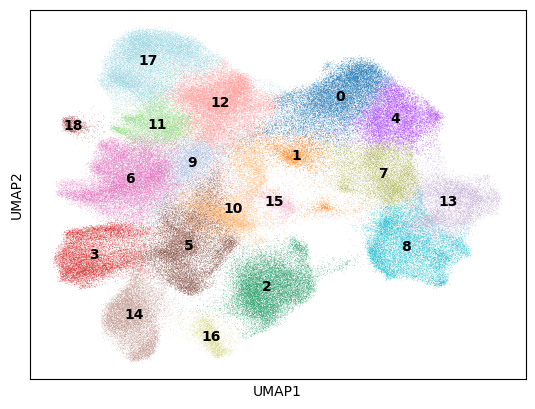

In [ ]:
sc.pl.umap(adata, color="leiden", legend_loc="on data", title="Leiden clusters in gene expression space")

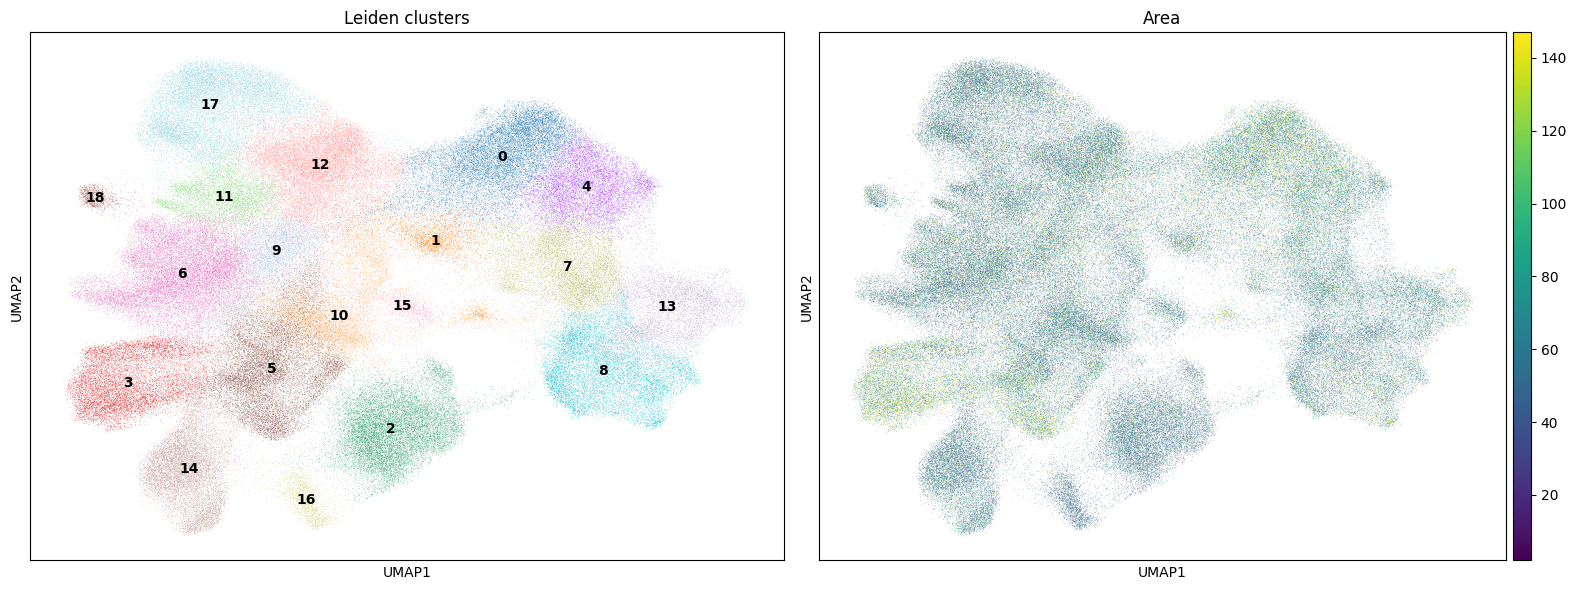

In [13]:

import matplotlib.pyplot as plt

# Side by side: Leiden clusters + Area
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc.pl.umap(adata, color="leiden", legend_loc="on data", ax=axes[0], show=False, title="Leiden clusters")
sc.pl.umap(adata, color="Area", ax=axes[1], show=False, title="Area", vmax=adata.obs["Area"].quantile(0.95))

plt.tight_layout()
plt.savefig("umap_leiden_area.png", dpi=200, bbox_inches="tight")
plt.show()

In [15]:
import numpy as np
import pandas as pd

_DROP_COLUMNS = {
    "Center_X", "Center_Y",
    "BoundingBoxMinimum_X", "BoundingBoxMaximum_X",
    "BoundingBoxMinimum_Y", "BoundingBoxMaximum_Y",
    "Orientation",
    "NormalizedMoment_1_0", "NormalizedMoment_0_0", "NormalizedMoment_0_1",
}

def get_morphology_columns(obs_columns) -> list[str]:
    cols = [c for c in obs_columns if c and c[0].isupper()]
    cols = [c for c in cols if c not in _DROP_COLUMNS]
    cols = [c for c in cols if not c.startswith("SpatialMoment_")]
    return cols

morph_cols = get_morphology_columns(adata.obs.columns)

ratios = {}

for col in morph_cols:
    values = pd.to_numeric(adata.obs[col], errors="coerce").replace([np.inf, -np.inf], np.nan)
    total_var = values.var()

    if pd.isna(total_var) or total_var == 0:
        ratios[col] = np.nan
        continue

    group_means = values.groupby(adata.obs["leiden"].astype(str)).mean()
    ratios[col] = group_means.var() / total_var

top = sorted(
    ((k, v) for k, v in ratios.items() if pd.notna(v)),
    key=lambda x: -x[1],
)

for name, r in top[:15]:
    print(f"{name:35s} {r:.3f}")

MeanRadius                          0.057
InertiaTensorEigenvalues_1          0.056
MaximumRadius                       0.054
MinorAxisLength                     0.051
Eccentricity                        0.051
FilledArea                          0.049
Area                                0.049
CentralMoment_0_0                   0.049
MedianRadius                        0.048
EquivalentDiameter                  0.047
ConvexArea                          0.045
HuMoment_0                          0.044
Compactness                         0.042
PerimeterCrofton                    0.041
MajorAxisLength                     0.041


/var/folders/m8/trnx4qbn4c3_95k5_lkbmxwh0000gn/T/ipykernel_13292/2714416313.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(x="leiden", y=feat, data=adata.obs, palette="viridis", ax=ax)
/var/folders/m8/trnx4qbn4c3_95k5_lkbmxwh0000gn/T/ipykernel_13292/2714416313.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(x="leiden", y=feat, data=adata.obs, palette="viridis", ax=ax)
/var/folders/m8/trnx4qbn4c3_95k5_lkbmxwh0000gn/T/ipykernel_13292/2714416313.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(x="leiden", y=feat, data=adata.obs, palett

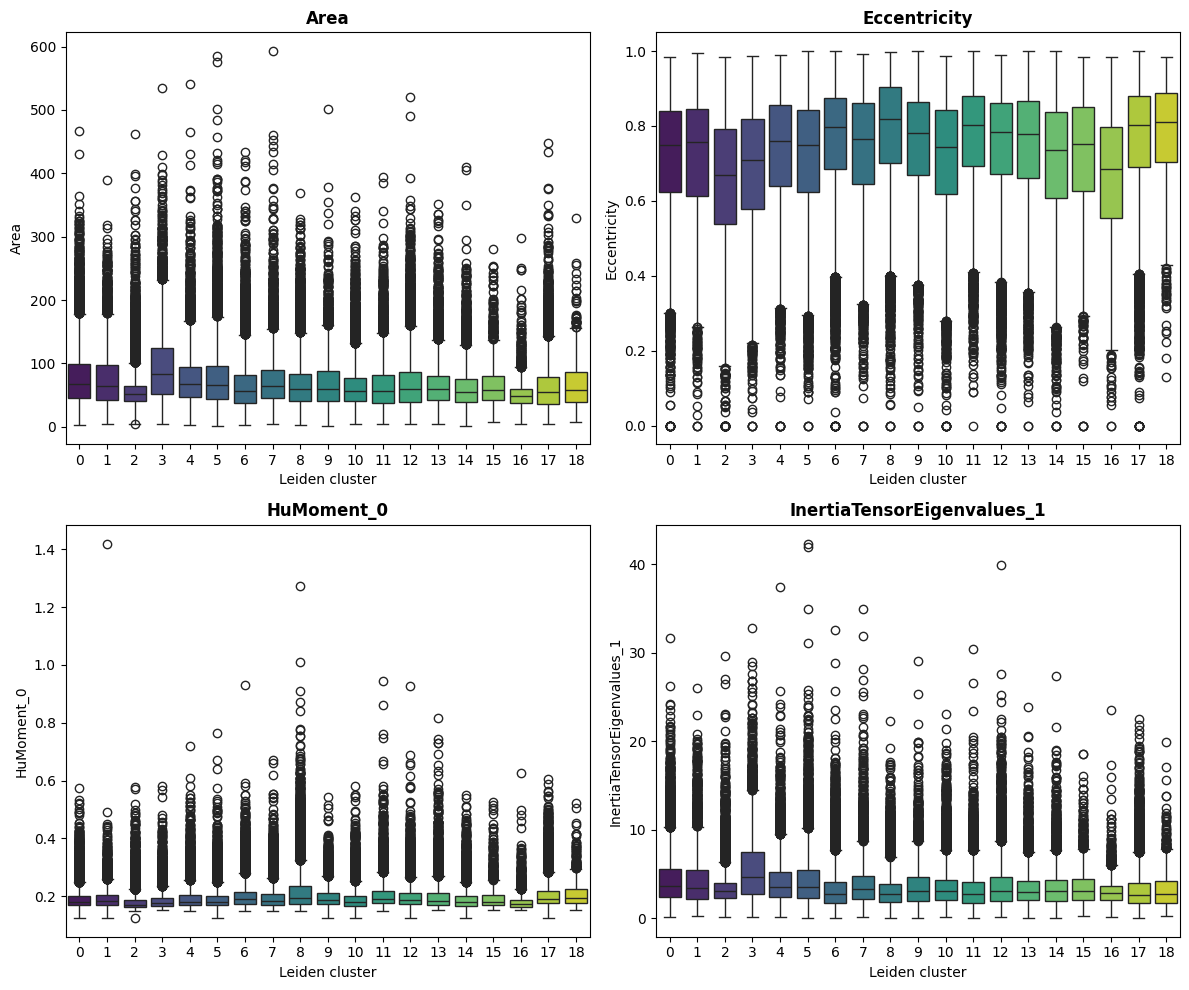

In [11]:
FEATURES_TO_COMPARE = ['Area', 'Eccentricity', 'HuMoment_0', 'InertiaTensorEigenvalues_1']
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for ax, feat in zip(axes, ["Area", "Eccentricity", "HuMoment_0", "InertiaTensorEigenvalues_1"]):
    sb.boxplot(x="leiden", y=feat, data=adata.obs, palette="viridis", ax=ax)
    # ax.set_title(feat, fontsize=16, fontweight="bold")
    ax.set_title(feat, fontweight="bold")
    ax.set_xlabel("Leiden cluster")
plt.tight_layout()
plt.savefig("boxplots_by_cluster.png", dpi=200, bbox_inches="tight")

In [3]:
adata = sc.read_h5ad("data/whole_dataset_test.h5ad")
len(adata)

19471